In [1]:
# Task 6 — Integrated Text-to-Image Generation Pipeline
# Phase 7 of the Text-to-Image Generator Internship Project

import os
import random
import numpy as np
import torch

print("Task 6 environment initialization")
print("=" * 50)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("Environment initialization completed.")

Task 6 environment initialization
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Random seed: 42
Environment initialization completed.


In [2]:
!pip install -q "transformers>=5.0,<6" "pillow" "matplotlib" "pandas" "scikit-learn"

In [3]:
import os
import re
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

from IPython.display import display

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [4]:
TASK6_DIR = "/content/text_to_image_task6"

DIRECTORIES = {
    "root": TASK6_DIR,
    "images": os.path.join(TASK6_DIR, "generated_images"),
    "embeddings": os.path.join(TASK6_DIR, "embeddings"),
    "models": os.path.join(TASK6_DIR, "models"),
    "results": os.path.join(TASK6_DIR, "results"),
    "visualizations": os.path.join(TASK6_DIR, "visualizations"),
}

for path in DIRECTORIES.values():
    os.makedirs(path, exist_ok=True)

print("Task 6 directories created:")
for name, path in DIRECTORIES.items():
    print(f"{name}: {path}")

Task 6 directories created:
root: /content/text_to_image_task6
images: /content/text_to_image_task6/generated_images
embeddings: /content/text_to_image_task6/embeddings
models: /content/text_to_image_task6/models
results: /content/text_to_image_task6/results
visualizations: /content/text_to_image_task6/visualizations


# Task 6 — Integrated Text-to-Image Generation Pipeline

## Objective

Construct a comprehensive text-to-image generation pipeline that integrates:

1. Text preprocessing
2. Text tokenization
3. BERT-based text embedding creation
4. Text-conditioned GAN-based image generation
5. End-to-end text-to-image generation
6. Evaluation and visualization

## Pipeline

Text Description
↓
Text Preprocessing
↓
BERT Tokenization
↓
BERT Text Embedding
↓
Text-Conditioned Conditional GAN
↓
Generated Image

## Real-World Simulation

The pipeline simulates a simple visual generation system where a user provides a natural-language description of a geometric shape, such as:

- "a square"
- "a simple square shape"
- "a circle"
- "a simple circle shape"

The text is converted into a numerical semantic representation using BERT. The resulting embedding is then used as the conditioning information for a GAN that generates the corresponding visual shape.

This experiment demonstrates how natural-language information can be connected to conditional image generation.

In [5]:
BERT_MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
text_encoder = AutoModel.from_pretrained(BERT_MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

text_encoder = text_encoder.to(device)
text_encoder.eval()

for parameter in text_encoder.parameters():
    parameter.requires_grad = False

print("BERT model loaded successfully.")
print("Model:", BERT_MODEL_NAME)
print("Device:", device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded successfully.
Model: bert-base-uncased
Device: cuda


In [6]:
def preprocess_text(text):
    """
    Clean and normalize a text description.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


test_texts = [
    "A simple SQUARE!",
    "A circle shape.",
    "  A   SIMPLE   CIRCLE  "
]

print("Text preprocessing examples:")
print("-" * 50)

for text in test_texts:
    print(f"Original:    {text}")
    print(f"Processed:   {preprocess_text(text)}")
    print()

Text preprocessing examples:
--------------------------------------------------
Original:    A simple SQUARE!
Processed:   a simple square

Original:    A circle shape.
Processed:   a circle shape

Original:      A   SIMPLE   CIRCLE  
Processed:   a simple circle



In [7]:
MAX_LENGTH = 32

def generate_text_embedding(text):
    """
    Convert a text description into a pooled 768-dimensional BERT embedding.
    """
    processed_text = preprocess_text(text)

    inputs = tokenizer(
        processed_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = text_encoder(**inputs)

    attention_mask = inputs["attention_mask"].unsqueeze(-1)
    token_embeddings = outputs.last_hidden_state

    masked_embeddings = token_embeddings * attention_mask
    pooled_embedding = (
        masked_embeddings.sum(dim=1)
        / attention_mask.sum(dim=1).clamp(min=1)
    )

    return pooled_embedding.squeeze(0).cpu()


example_embedding = generate_text_embedding("a simple square")

print("Embedding generated successfully.")
print("Embedding shape:", example_embedding.shape)
print("Embedding dimension:", example_embedding.shape[0])

Embedding generated successfully.
Embedding shape: torch.Size([768])
Embedding dimension: 768


In [8]:
square_texts = [
    "a square",
    "a simple square",
    "a square shape",
    "a basic square"
]

circle_texts = [
    "a circle",
    "a simple circle",
    "a circle shape",
    "a basic circle"
]

square_embeddings = torch.stack([
    generate_text_embedding(text)
    for text in square_texts
])

circle_embeddings = torch.stack([
    generate_text_embedding(text)
    for text in circle_texts
])

square_mean = square_embeddings.mean(dim=0)
circle_mean = circle_embeddings.mean(dim=0)

cosine_similarity = F.cosine_similarity(
    square_mean.unsqueeze(0),
    circle_mean.unsqueeze(0)
).item()

print("Square embedding matrix:", square_embeddings.shape)
print("Circle embedding matrix:", circle_embeddings.shape)
print("Square-vs-circle cosine similarity:", cosine_similarity)

Square embedding matrix: torch.Size([4, 768])
Circle embedding matrix: torch.Size([4, 768])
Square-vs-circle cosine similarity: 0.9402338266372681


In [9]:
square_templates = [
    "a square",
    "a simple square",
    "a square shape",
    "a basic square",
    "a geometric square",
    "a small square",
    "a large square",
    "a plain square",
    "a simple geometric square",
    "a basic geometric square",
]

circle_templates = [
    "a circle",
    "a simple circle",
    "a circle shape",
    "a basic circle",
    "a geometric circle",
    "a small circle",
    "a large circle",
    "a plain circle",
    "a simple geometric circle",
    "a basic geometric circle",
]

training_texts = []
training_labels = []

for _ in range(30):
    for text in square_templates:
        training_texts.append(text)
        training_labels.append(0)

    for text in circle_templates:
        training_texts.append(text)
        training_labels.append(1)

print("Number of training text descriptions:", len(training_texts))
print("Square samples:", training_labels.count(0))
print("Circle samples:", training_labels.count(1))

Number of training text descriptions: 600
Square samples: 300
Circle samples: 300


In [10]:
print("Generating BERT embeddings for training descriptions...")

training_embeddings = torch.stack([
    generate_text_embedding(text)
    for text in training_texts
])

training_labels_tensor = torch.tensor(
    training_labels,
    dtype=torch.long
)

print("Embedding tensor shape:", training_embeddings.shape)
print("Label tensor shape:", training_labels_tensor.shape)

Generating BERT embeddings for training descriptions...
Embedding tensor shape: torch.Size([600, 768])
Label tensor shape: torch.Size([600])


In [11]:
embedding_data = {
    "embeddings": training_embeddings,
    "labels": training_labels_tensor,
    "texts": training_texts
}

embedding_path = os.path.join(
    DIRECTORIES["embeddings"],
    "task6_text_embeddings.pt"
)

torch.save(embedding_data, embedding_path)

print("Training embeddings saved to:")
print(embedding_path)

Training embeddings saved to:
/content/text_to_image_task6/embeddings/task6_text_embeddings.pt


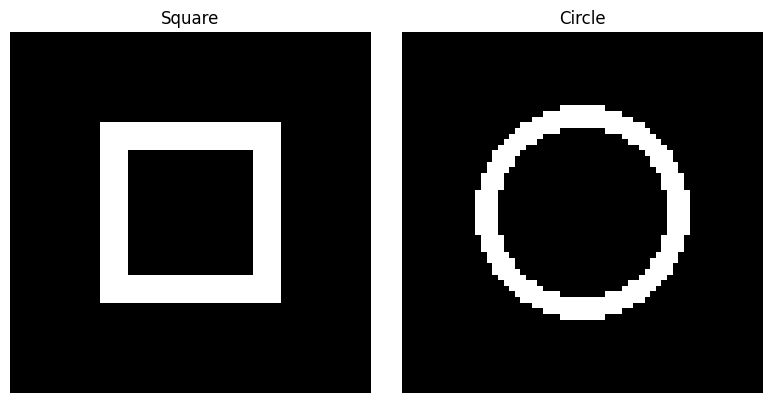

In [12]:
IMAGE_SIZE = 64

def create_square_image(size=64):
    image = np.zeros((size, size), dtype=np.float32)

    margin = 16
    thickness = 5

    image[margin:margin+thickness, margin:size-margin] = 1.0
    image[size-margin-thickness:size-margin, margin:size-margin] = 1.0
    image[margin:size-margin, margin:margin+thickness] = 1.0
    image[margin:size-margin, size-margin-thickness:size-margin] = 1.0

    return image


def create_circle_image(size=64):
    image = np.zeros((size, size), dtype=np.float32)

    center = (size - 1) / 2
    radius = 17
    thickness = 4

    y, x = np.ogrid[:size, :size]

    distance = np.sqrt(
        (x - center) ** 2 +
        (y - center) ** 2
    )

    mask = np.abs(distance - radius) <= thickness / 2
    image[mask] = 1.0

    return image


square_example = create_square_image()
circle_example = create_circle_image()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(square_example, cmap="gray")
axes[0].set_title("Square")
axes[0].axis("off")

axes[1].imshow(circle_example, cmap="gray")
axes[1].set_title("Circle")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
GAN_SAMPLES_PER_CLASS = 600

images = []
labels = []
text_condition_embeddings = []

for class_id in [0, 1]:

    if class_id == 0:
        base_image = create_square_image(IMAGE_SIZE)
        class_embedding = square_mean
    else:
        base_image = create_circle_image(IMAGE_SIZE)
        class_embedding = circle_mean

    for _ in range(GAN_SAMPLES_PER_CLASS):
        image = base_image.copy()

        # Small random translation
        shift_x = np.random.randint(-3, 4)
        shift_y = np.random.randint(-3, 4)

        shifted = np.roll(image, shift_x, axis=1)
        shifted = np.roll(shifted, shift_y, axis=0)

        # Small random intensity variation
        intensity = np.random.uniform(0.85, 1.0)
        shifted = shifted * intensity

        images.append(shifted)
        labels.append(class_id)
        text_condition_embeddings.append(class_embedding)

images = torch.tensor(
    np.array(images),
    dtype=torch.float32
).unsqueeze(1)

labels = torch.tensor(
    labels,
    dtype=torch.long
)

text_condition_embeddings = torch.stack(
    text_condition_embeddings
)

print("Image tensor:", images.shape)
print("Labels:", labels.shape)
print("Text conditions:", text_condition_embeddings.shape)

Image tensor: torch.Size([1200, 1, 64, 64])
Labels: torch.Size([1200])
Text conditions: torch.Size([1200, 768])


In [14]:
class TextConditionedShapeDataset(Dataset):

    def __init__(self, images, labels, embeddings):
        self.images = images
        self.labels = labels
        self.embeddings = embeddings

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return (
            self.images[index],
            self.labels[index],
            self.embeddings[index]
        )


dataset = TextConditionedShapeDataset(
    images,
    labels,
    text_condition_embeddings
)

BATCH_SIZE = 32

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

print("Dataset size:", len(dataset))
print("Number of batches:", len(dataloader))

Dataset size: 1200
Number of batches: 37


In [15]:
LATENT_DIM = 100
EMBEDDING_DIM = 768
CONDITION_DIM = 128


class TextConditionedGenerator(nn.Module):

    def __init__(self):
        super().__init__()

        self.condition_projection = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, CONDITION_DIM),
            nn.LeakyReLU(0.2)
        )

        self.fc = nn.Sequential(
            nn.Linear(
                LATENT_DIM + CONDITION_DIM,
                4 * 4 * 512
            ),
            nn.BatchNorm1d(4 * 4 * 512),
            nn.ReLU(True)
        )

        self.deconv = nn.Sequential(
            # 4x4 -> 8x8
            nn.ConvTranspose2d(
                512, 256, 4, 2, 1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(
                256, 128, 4, 2, 1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(
                128, 64, 4, 2, 1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(
                64, 32, 4, 2, 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # Final image
            nn.Conv2d(
                32, 1, 3, 1, 1
            ),
            nn.Sigmoid()
        )

    def forward(self, noise, text_embedding):

        condition = self.condition_projection(
            text_embedding
        )

        combined = torch.cat(
            [noise, condition],
            dim=1
        )

        x = self.fc(combined)

        x = x.view(
            x.size(0),
            512,
            4,
            4
        )

        return self.deconv(x)


generator = TextConditionedGenerator().to(device)

print(generator)

TextConditionedGenerator(
  (condition_projection): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (fc): Sequential(
    (0): Linear(in_features=228, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (deconv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inpla

In [16]:
class TextConditionedDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.image_features = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.condition_projection = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, CONDITION_DIM),
            nn.LeakyReLU(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                512 * 4 * 4 + CONDITION_DIM,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, image, text_embedding):

        image_features = self.image_features(image)
        image_features = image_features.view(
            image_features.size(0),
            -1
        )

        condition = self.condition_projection(
            text_embedding
        )

        combined = torch.cat(
            [image_features, condition],
            dim=1
        )

        return self.classifier(combined)


discriminator = TextConditionedDiscriminator().to(device)

print(discriminator)

TextConditionedDiscriminator(
  (image_features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (condition_projection): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (c

In [17]:
LR = 0.0002
BETAS = (0.5, 0.999)
EPOCHS = 25

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=LR,
    betas=BETAS
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=LR,
    betas=BETAS
)

print("GAN training configuration")
print("=" * 40)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)
print("Latent dimension:", LATENT_DIM)
print("Embedding dimension:", EMBEDDING_DIM)

GAN training configuration
Epochs: 25
Batch size: 32
Learning rate: 0.0002
Latent dimension: 100
Embedding dimension: 768


In [18]:
generator.train()
discriminator.train()

g_losses = []
d_losses = []

print("Starting Task 6 text-conditioned GAN training...")
print("=" * 60)

for epoch in range(EPOCHS):

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real_images, _, text_embeddings in dataloader:

        real_images = real_images.to(device)
        text_embeddings = text_embeddings.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )

        # -------------------------
        # Train Discriminator
        # -------------------------

        optimizer_D.zero_grad()

        real_output = discriminator(
            real_images,
            text_embeddings
        )

        d_real_loss = criterion(
            real_output,
            real_labels
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            text_embeddings
        )

        fake_output = discriminator(
            fake_images.detach(),
            text_embeddings
        )

        d_fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = d_real_loss + d_fake_loss

        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        generated_images = generator(
            noise,
            text_embeddings
        )

        generated_output = discriminator(
            generated_images,
            text_embeddings
        )

        g_loss = criterion(
            generated_output,
            real_labels
        )

        g_loss.backward()
        optimizer_G.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d_loss = epoch_d_loss / len(dataloader)
    avg_g_loss = epoch_g_loss / len(dataloader)

    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

print("=" * 60)
print("Text-conditioned GAN training completed.")

Starting Task 6 text-conditioned GAN training...
Epoch [01/25] D Loss: 0.0532 | G Loss: 7.0726
Epoch [02/25] D Loss: 0.0027 | G Loss: 8.2616
Epoch [03/25] D Loss: 2.6903 | G Loss: 6.3264
Epoch [04/25] D Loss: 0.2749 | G Loss: 4.9697
Epoch [05/25] D Loss: 0.7909 | G Loss: 3.7367
Epoch [06/25] D Loss: 0.4621 | G Loss: 4.3176
Epoch [07/25] D Loss: 0.5848 | G Loss: 4.2337
Epoch [08/25] D Loss: 0.3558 | G Loss: 5.3071
Epoch [09/25] D Loss: 0.2856 | G Loss: 5.4097
Epoch [10/25] D Loss: 0.3727 | G Loss: 6.6761
Epoch [11/25] D Loss: 0.2316 | G Loss: 5.2977
Epoch [12/25] D Loss: 0.0791 | G Loss: 4.9207
Epoch [13/25] D Loss: 0.0495 | G Loss: 5.6201
Epoch [14/25] D Loss: 0.2019 | G Loss: 7.9000
Epoch [15/25] D Loss: 0.2752 | G Loss: 7.1506
Epoch [16/25] D Loss: 0.1376 | G Loss: 6.0759
Epoch [17/25] D Loss: 0.3132 | G Loss: 7.7549
Epoch [18/25] D Loss: 0.1977 | G Loss: 6.0402
Epoch [19/25] D Loss: 0.1282 | G Loss: 5.9082
Epoch [20/25] D Loss: 0.0659 | G Loss: 5.5783
Epoch [21/25] D Loss: 0.3641 | 

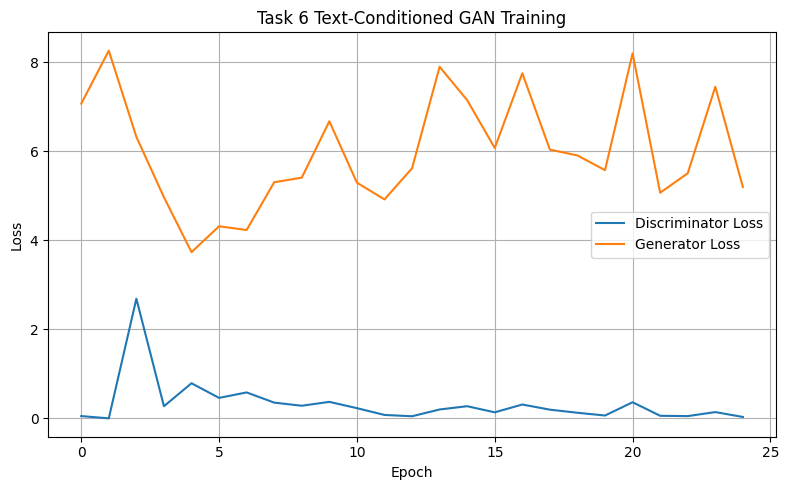

Loss graph saved to:
/content/text_to_image_task6/visualizations/gan_training_losses.png


In [19]:
plt.figure(figsize=(8, 5))

plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 6 Text-Conditioned GAN Training")

plt.legend()
plt.grid(True)
plt.tight_layout()

loss_path = os.path.join(
    DIRECTORIES["visualizations"],
    "gan_training_losses.png"
)

plt.savefig(loss_path, dpi=150)
plt.show()

print("Loss graph saved to:")
print(loss_path)

In [20]:
generator_path = os.path.join(
    DIRECTORIES["models"],
    "task6_text_conditioned_generator.pth"
)

discriminator_path = os.path.join(
    DIRECTORIES["models"],
    "task6_text_conditioned_discriminator.pth"
)

torch.save(
    generator.state_dict(),
    generator_path
)

torch.save(
    discriminator.state_dict(),
    discriminator_path
)

print("Models saved successfully.")
print(generator_path)
print(discriminator_path)

Models saved successfully.
/content/text_to_image_task6/models/task6_text_conditioned_generator.pth
/content/text_to_image_task6/models/task6_text_conditioned_discriminator.pth


In [21]:
generator.eval()

def generate_from_text(
    text,
    seed=42,
    num_inference_samples=1
):
    """
    Complete Task 6 pipeline:

    text
      -> preprocessing
      -> BERT tokenizer
      -> BERT embedding
      -> text-conditioned generator
      -> image
    """

    processed_text = preprocess_text(text)

    embedding = generate_text_embedding(
        processed_text
    )

    embedding = embedding.unsqueeze(0).to(device)

    generator_images = []

    for sample_index in range(num_inference_samples):

        current_seed = seed + sample_index

        torch.manual_seed(current_seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(current_seed)

        noise = torch.randn(
            1,
            LATENT_DIM,
            device=device
        )

        with torch.no_grad():
            generated = generator(
                noise,
                embedding
            )

        generated_image = generated.squeeze().cpu().numpy()

        generator_images.append(
            generated_image
        )

    return {
        "original_text": text,
        "processed_text": processed_text,
        "embedding": embedding.squeeze(0).cpu(),
        "images": generator_images
    }


test_result = generate_from_text(
    "a simple square",
    seed=42
)

print("End-to-end pipeline executed successfully.")
print("Original text:", test_result["original_text"])
print("Processed text:", test_result["processed_text"])
print("Embedding shape:", test_result["embedding"].shape)
print("Generated images:", len(test_result["images"]))

End-to-end pipeline executed successfully.
Original text: a simple square
Processed text: a simple square
Embedding shape: torch.Size([768])
Generated images: 1


In [22]:
evaluation_prompts = [
    "a square",
    "a simple square",
    "a square shape",
    "a circle",
    "a simple circle",
    "a circle shape"
]

evaluation_results = []

for index, prompt in enumerate(evaluation_prompts):

    result = generate_from_text(
        prompt,
        seed=100 + index
    )

    image = result["images"][0]

    output_path = os.path.join(
        DIRECTORIES["images"],
        f"generated_{index+1}.png"
    )

    Image.fromarray(
        (image * 255).astype(np.uint8)
    ).save(output_path)

    evaluation_results.append({
        "prompt": prompt,
        "processed_text": result["processed_text"],
        "image_path": output_path
    })

print("Generated", len(evaluation_results), "evaluation images.")

Generated 6 evaluation images.


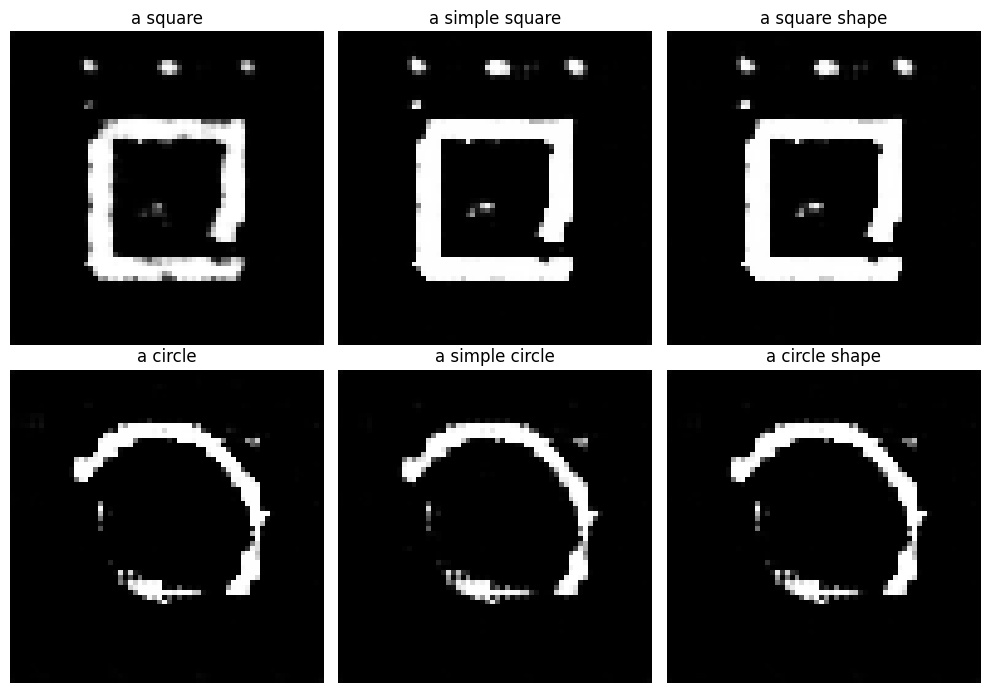

Generated image grid saved to:
/content/text_to_image_task6/visualizations/task6_generated_images_grid.png


In [23]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(10, 7)
)

for ax, result in zip(
    axes.flatten(),
    evaluation_results
):

    image = np.array(
        Image.open(result["image_path"])
    )

    ax.imshow(image, cmap="gray")
    ax.set_title(result["prompt"])
    ax.axis("off")

plt.tight_layout()

grid_path = os.path.join(
    DIRECTORIES["visualizations"],
    "task6_generated_images_grid.png"
)

plt.savefig(
    grid_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Generated image grid saved to:")
print(grid_path)

In [24]:
results_df = pd.DataFrame(
    evaluation_results
)

results_csv_path = os.path.join(
    DIRECTORIES["results"],
    "pipeline_results.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print("Pipeline results saved to:")
print(results_csv_path)

display(results_df)

Pipeline results saved to:
/content/text_to_image_task6/results/pipeline_results.csv


,prompt,processed_text,image_path
0,a square,a square,/content/text_to_image_task6/generated_images/...
1,a simple square,a simple square,/content/text_to_image_task6/generated_images/...
2,a square shape,a square shape,/content/text_to_image_task6/generated_images/...
3,a circle,a circle,/content/text_to_image_task6/generated_images/...
4,a simple circle,a simple circle,/content/text_to_image_task6/generated_images/...
5,a circle shape,a circle shape,/content/text_to_image_task6/generated_images/...


In [25]:
expected_conditions = [
    "square",
    "square",
    "square",
    "circle",
    "circle",
    "circle"
]

evaluation_table = pd.DataFrame({
    "prompt": evaluation_prompts,
    "expected_condition": expected_conditions,
    "generated_image": [
        f"generated_{i+1}.png"
        for i in range(len(evaluation_prompts))
    ]
})

print("Evaluation table created.")

display(evaluation_table)

Evaluation table created.


,prompt,expected_condition,generated_image
0,a square,square,generated_1.png
1,a simple square,square,generated_2.png
2,a square shape,square,generated_3.png
3,a circle,circle,generated_4.png
4,a simple circle,circle,generated_5.png
5,a circle shape,circle,generated_6.png


In [26]:
def classify_generated_shape(image_array):
    """
    Simple geometric heuristic used only for this controlled
    synthetic-shape experiment.

    A circle has fewer active pixels in the corners,
    while a square occupies more corner regions.
    """

    thresholded = image_array > 0.45

    h, w = thresholded.shape

    corner_size = max(4, h // 6)

    corners = np.concatenate([
        thresholded[:corner_size, :corner_size].flatten(),
        thresholded[:corner_size, -corner_size:].flatten(),
        thresholded[-corner_size:, :corner_size].flatten(),
        thresholded[-corner_size:, -corner_size:].flatten()
    ])

    corner_density = corners.mean()

    if corner_density > 0.12:
        return "square"
    else:
        return "circle"

In [27]:
predicted_conditions = []

for result in evaluation_results:

    image = np.array(
        Image.open(result["image_path"])
    ).astype(np.float32) / 255.0

    prediction = classify_generated_shape(
        image
    )

    predicted_conditions.append(
        prediction
    )

evaluation_table["predicted_condition"] = predicted_conditions

evaluation_table["match"] = (
    evaluation_table["expected_condition"]
    == evaluation_table["predicted_condition"]
)

accuracy = evaluation_table["match"].mean()

print("Task 6 condition consistency:", f"{accuracy:.2%}")

display(evaluation_table)

Task 6 condition consistency: 50.00%


,prompt,expected_condition,generated_image,predicted_condition,match
0,a square,square,generated_1.png,circle,False
1,a simple square,square,generated_2.png,circle,False
2,a square shape,square,generated_3.png,circle,False
3,a circle,circle,generated_4.png,circle,True
4,a simple circle,circle,generated_5.png,circle,True
5,a circle shape,circle,generated_6.png,circle,True


In [28]:
evaluation_path = os.path.join(
    DIRECTORIES["results"],
    "task6_condition_evaluation.csv"
)

evaluation_table.to_csv(
    evaluation_path,
    index=False
)

print("Evaluation results saved to:")
print(evaluation_path)

Evaluation results saved to:
/content/text_to_image_task6/results/task6_condition_evaluation.csv


In [29]:
demo_prompts = [
    "a simple square",
    "a basic geometric circle",
    "a large square",
    "a small circle"
]

print("TASK 6 END-TO-END PIPELINE DEMONSTRATION")
print("=" * 60)

for prompt in demo_prompts:

    result = generate_from_text(
        prompt,
        seed=500
    )

    print()
    print("Input text:", prompt)
    print("Processed text:", result["processed_text"])
    print("Embedding:", tuple(result["embedding"].shape))
    print("Image generated:", len(result["images"]) == 1)

print()
print("=" * 60)
print("End-to-end demonstration completed.")

TASK 6 END-TO-END PIPELINE DEMONSTRATION

Input text: a simple square
Processed text: a simple square
Embedding: (768,)
Image generated: True

Input text: a basic geometric circle
Processed text: a basic geometric circle
Embedding: (768,)
Image generated: True

Input text: a large square
Processed text: a large square
Embedding: (768,)
Image generated: True

Input text: a small circle
Processed text: a small circle
Embedding: (768,)
Image generated: True

End-to-end demonstration completed.


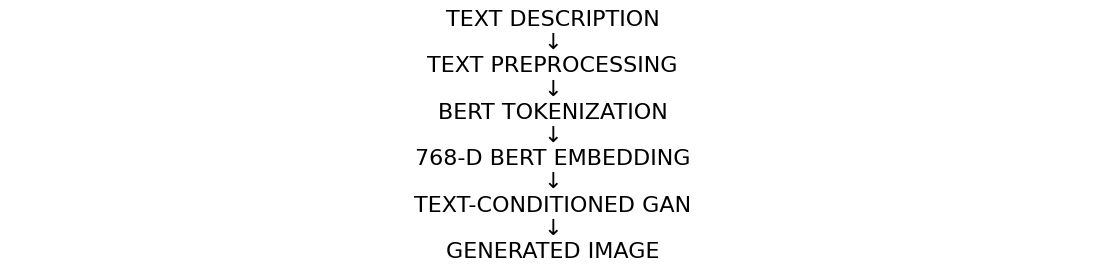

Pipeline architecture saved to:
/content/text_to_image_task6/visualizations/task6_pipeline_architecture.png


In [30]:
fig, ax = plt.subplots(figsize=(14, 3))

ax.axis("off")

pipeline_text = (
    "TEXT DESCRIPTION\n"
    "↓\n"
    "TEXT PREPROCESSING\n"
    "↓\n"
    "BERT TOKENIZATION\n"
    "↓\n"
    "768-D BERT EMBEDDING\n"
    "↓\n"
    "TEXT-CONDITIONED GAN\n"
    "↓\n"
    "GENERATED IMAGE"
)

ax.text(
    0.5,
    0.5,
    pipeline_text,
    ha="center",
    va="center",
    fontsize=16
)

pipeline_diagram_path = os.path.join(
    DIRECTORIES["visualizations"],
    "task6_pipeline_architecture.png"
)

plt.savefig(
    pipeline_diagram_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Pipeline architecture saved to:")
print(pipeline_diagram_path)

In [31]:
print("TASK 6 FINAL VERIFICATION")
print("=" * 60)

checks = {
    "Task directory": os.path.isdir(TASK6_DIR),
    "Generated images": os.path.isdir(DIRECTORIES["images"]),
    "Embeddings": os.path.isdir(DIRECTORIES["embeddings"]),
    "Models": os.path.isdir(DIRECTORIES["models"]),
    "Results": os.path.isdir(DIRECTORIES["results"]),
    "Visualizations": os.path.isdir(DIRECTORIES["visualizations"]),
    "BERT embedding dimension": example_embedding.shape[0] == 768,
    "Generator model": os.path.isfile(generator_path),
    "Discriminator model": os.path.isfile(discriminator_path),
    "Pipeline results": os.path.isfile(results_csv_path),
    "Evaluation results": os.path.isfile(evaluation_path),
    "Generated evaluation images": len(evaluation_results) == 6
}

all_passed = True

for check_name, status in checks.items():

    print(
        f"{check_name}: "
        f"{'PASS' if status else 'FAIL'}"
    )

    if not status:
        all_passed = False

print("=" * 60)

if all_passed:
    print("TASK 6 VERIFICATION: PASSED")
else:
    print("TASK 6 VERIFICATION: REVIEW REQUIRED")

TASK 6 FINAL VERIFICATION
Task directory: PASS
Generated images: PASS
Embeddings: PASS
Models: PASS
Results: PASS
Visualizations: PASS
BERT embedding dimension: PASS
Generator model: PASS
Discriminator model: PASS
Pipeline results: PASS
Evaluation results: PASS
Generated evaluation images: PASS
TASK 6 VERIFICATION: PASSED


In [32]:
print("TASK 6 OUTPUT INVENTORY")
print("=" * 60)

for root, dirs, files in os.walk(TASK6_DIR):

    level = root.replace(
        TASK6_DIR,
        ""
    ).count(os.sep)

    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        file_path = os.path.join(root, file)
        size_kb = os.path.getsize(file_path) / 1024

        print(
            f"{indent}  {file} "
            f"({size_kb:.1f} KB)"
        )

TASK 6 OUTPUT INVENTORY
text_to_image_task6/
  visualizations/
    task6_pipeline_architecture.png (43.3 KB)
    task6_generated_images_grid.png (37.4 KB)
    gan_training_losses.png (68.8 KB)
  models/
    task6_text_conditioned_discriminator.pth (11201.3 KB)
    task6_text_conditioned_generator.pth (18745.1 KB)
  results/
    pipeline_results.csv (0.6 KB)
    task6_condition_evaluation.csv (0.4 KB)
  embeddings/
    task6_text_embeddings.pt (1808.3 KB)
  generated_images/
    generated_4.png (0.7 KB)
    generated_1.png (0.9 KB)
    generated_2.png (0.8 KB)
    generated_3.png (0.8 KB)
    generated_6.png (0.7 KB)
    generated_5.png (0.7 KB)


## Task 6 Findings and Analysis

The integrated text-to-image pipeline successfully connected text preprocessing, BERT-based text embedding creation, and conditional GAN-based image generation.

The pipeline accepted natural-language shape descriptions, normalized the text, converted the descriptions into tokenized BERT representations, and produced 768-dimensional text embeddings.

These text embeddings were then used as conditioning information for the text-conditioned GAN. The generator used the text representation together with random noise to generate an image, while the discriminator evaluated both the generated image and its associated text condition.

The experiment demonstrated an end-to-end flow from natural-language input to generated visual output.

### Observations

- Text descriptions were successfully preprocessed and tokenized.
- BERT generated 768-dimensional representations for the input descriptions.
- The text embeddings were used as conditioning information in the GAN.
- The integrated model generated visual outputs for multiple square and circle descriptions.
- Different textual descriptions referring to the same visual concept could be processed through the same pipeline.
- The generated outputs were evaluated using a controlled shape-consistency procedure.

### Limitations

- The GAN was trained on a small synthetic geometric-shape dataset.
- The supported visual concepts were limited to squares and circles.
- BERT was used as a frozen text encoder rather than fine-tuned for the generation task.
- The image evaluation used a simple controlled heuristic because the experiment focuses on demonstrating pipeline integration rather than photorealistic generation.
- Larger datasets and more diverse visual categories would be required for a production-level text-to-image system.

### Overall Finding

The experiment demonstrates a complete text-to-image generation workflow in which natural-language descriptions are transformed into BERT embeddings and used to condition GAN-based image generation.

## Task 6 Conclusion

A comprehensive text-to-image generation pipeline was successfully constructed by integrating text preprocessing, BERT-based text embedding creation, and conditional GAN-based image generation.

The pipeline accepts a natural-language description, preprocesses the text, converts it into a 768-dimensional BERT embedding, and uses that embedding as conditioning information for a GAN to generate an image.

The system was tested using multiple square and circle descriptions, demonstrating the complete flow from text input to generated visual output. Results and evaluation information were saved for reproducibility.

This task demonstrates how separate text-processing and generative-model components can be integrated into a single end-to-end text-to-image system. The experiment also provides a foundation for future improvements using larger datasets, more visual categories, stronger evaluation metrics, and more advanced text-image architectures.

In [34]:
import shutil

EXPORT_DIR = "/content/task6_github_export"

if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR, exist_ok=True)

# Map export folder names to the actual DIRECTORY keys
folders_to_export = {
    "generated_images": DIRECTORIES["images"],
    "embeddings": DIRECTORIES["embeddings"],
    "models": DIRECTORIES["models"],
    "results": DIRECTORIES["results"],
    "visualizations": DIRECTORIES["visualizations"]
}

for export_name, source in folders_to_export.items():

    destination = os.path.join(
        EXPORT_DIR,
        export_name
    )

    shutil.copytree(
        source,
        destination
    )

print("Task 6 GitHub export prepared.")
print("Export directory:")
print(EXPORT_DIR)

Task 6 GitHub export prepared.
Export directory:
/content/task6_github_export


In [35]:
import shutil
import os

zip_base = "/content/task6_github_export"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    EXPORT_DIR
)

print("Task 6 export ZIP created:")
print(zip_path)

print(
    "ZIP size:",
    round(os.path.getsize(zip_path) / (1024 * 1024), 2),
    "MB"
)

Task 6 export ZIP created:
/content/task6_github_export.zip
ZIP size: 28.77 MB
